# Pronóstico de Ocupados — 13 Principales Ciudades y Áreas Metropolitanas
## Ejercicio en Clase: Métodos de Regresión con Tendencia y Estacionalidad
### Series de Tiempo — Pontificia Universidad Javeriana Cali

**Variable de interés:** Número de ocupados (en miles de personas), 13 ciudades principales.

**Objetivo:** Empleando la información del número de ocupados, encontrar el mejor pronóstico para los próximos 6 meses con los métodos de regresión con tendencia y estacionalidad vistos en clase (siguiendo el mismo pipeline aplicado anteriormente a la tasa de desempleo), y comparar el resultado contra el mejor modelo de suavización exponencial (ETS) encontrado en el ejercicio anterior.


## 1. Carga de paquetes

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from dateutil.relativedelta import relativedelta
from matplotlib import pyplot as plt
import pylab as py
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)


## 2. Carga de datos

Se utiliza el mismo archivo `datosEmpleo.xlsx` empleado en el ejercicio anterior de tendencia y estacionalidad, esta vez modelando la variable **Ocupados** (miles de personas) en lugar de la tasa de desempleo.


In [2]:
data = pd.read_excel("datosEmpleo.xlsx",
                      index_col="mes", parse_dates=True)
data = data.asfreq("MS")
print(data.shape)
data.head()


(222, 4)


,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


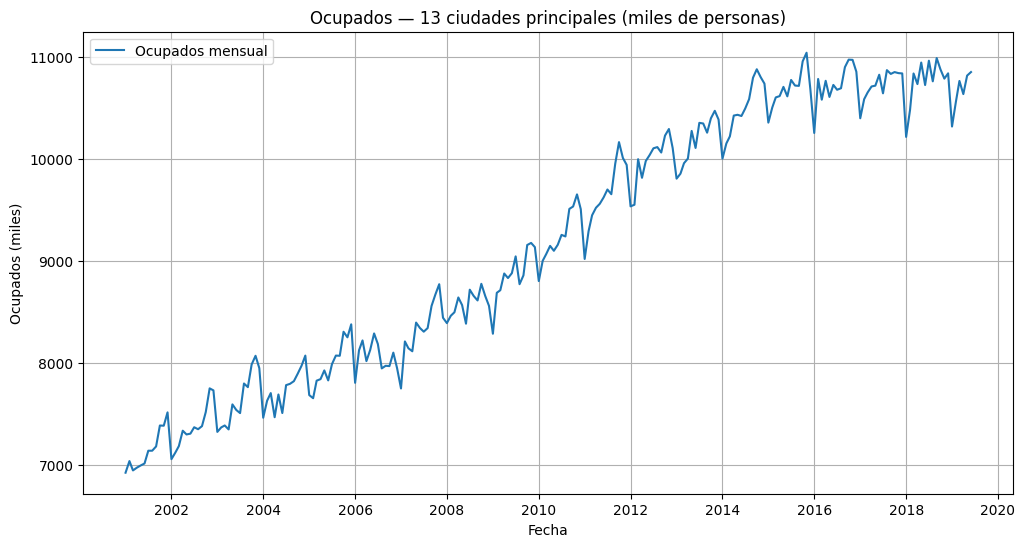

In [3]:
y = data["Ocupados"]

plt.plot(y, label="Ocupados mensual")
plt.title("Ocupados — 13 ciudades principales (miles de personas)")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles)")
plt.grid()
plt.legend()
plt.show()


La serie muestra una tendencia creciente sostenida entre 2001 y 2015, seguida de una desaceleración y mayor volatilidad de corto plazo a partir de 2015–2016 (incluyendo caídas puntuales pronunciadas, como la de enero de 2019). Este comportamiento es importante tenerlo presente al evaluar los modelos de tendencia global.


## 3. Partición de los datos

Se divide la serie en:

* **Entrenamiento:** enero de 2001 a junio de 2018 (210 observaciones).
* **Prueba (validación fuera de muestra):** julio de 2018 a junio de 2019 (12 observaciones).

Todos los modelos se ajustan únicamente con el conjunto de entrenamiento y se comparan con base en el **RMSE calculado sobre el conjunto de prueba**.


In [4]:
train = y.loc[:"2018-06-01"]
test  = y.loc["2018-07-01":"2019-06-01"]

print(f"Entrenamiento: {train.shape[0]} obs. ({train.index[0].date()} a {train.index[-1].date()})")
print(f"Prueba:        {test.shape[0]} obs. ({test.index[0].date()} a {test.index[-1].date()})")

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred))**2))


Entrenamiento: 210 obs. (2001-01-01 a 2018-06-01)
Prueba:        12 obs. (2018-07-01 a 2019-06-01)


## 4. Tendencia Lineal

In [5]:
n = train.shape[0]
x = np.linspace(1, n, n)
X = sm.add_constant(x)
lin = sm.OLS(train.values, X)
lin_t = lin.fit()
print(lin_t.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     5362.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          1.81e-150
Time:                        01:09:27   Log-Likelihood:                -1453.4
No. Observations:                 210   AIC:                             2911.
Df Residuals:                     208   BIC:                             2917.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6902.9155     34.123    202.295      0.0

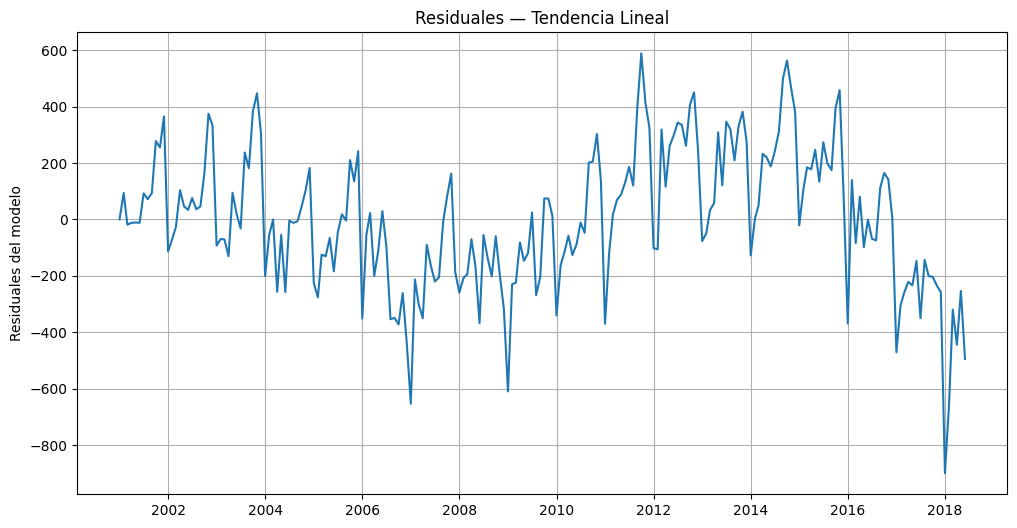

In [6]:
plt.ylabel("Residuales del modelo")
plt.plot(train.index, lin_t.resid)
plt.grid()
plt.title("Residuales — Tendencia Lineal")
plt.show()


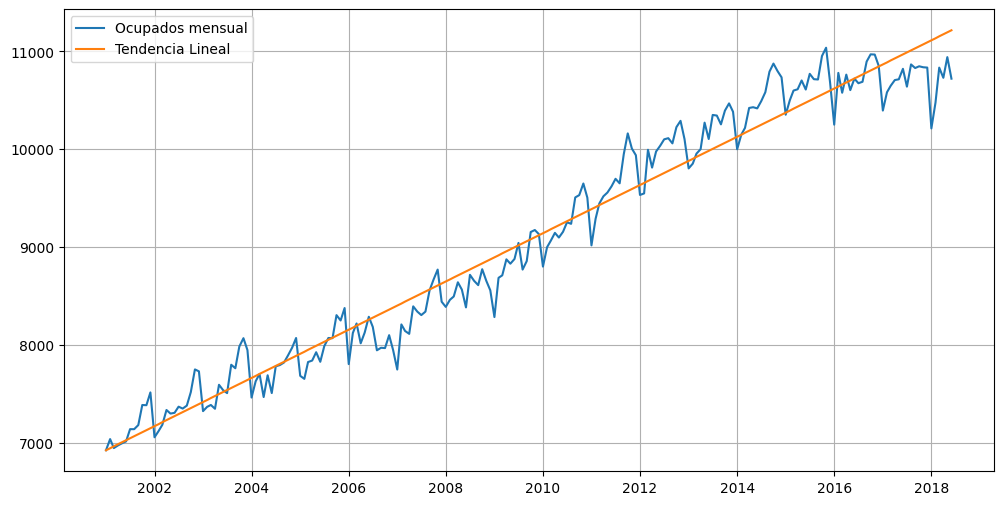

In [7]:
plt.plot(train.index, train.values, label="Ocupados mensual")
plt.plot(train.index, lin_t.fittedvalues, label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()


In [8]:
h = 12
x_for = np.linspace(n+1, n+h, h)
X_for = sm.add_constant(x_for)

dt = lin_t.get_prediction(X_for).summary_frame(alpha=0.05)
y_prd = dt["mean"]
yprd_ci_lower = dt["obs_ci_lower"]
yprd_ci_upper = dt["obs_ci_upper"]
preds_lin = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds_lin.columns = ["Point_forecast", "lower_95", "upper_95"]
preds_lin.index = test.index
print(preds_lin)


            Point_forecast      lower_95      upper_95
mes                                                   
2018-07-01    11236.027809  10745.703248  11726.352370
2018-08-01    11256.563887  10766.173250  11746.954523
2018-09-01    11277.099964  10786.642638  11767.557290
2018-10-01    11297.636042  10807.111411  11788.160672
2018-11-01    11318.172119  10827.579571  11808.764667
2018-12-01    11338.708196  10848.047117  11829.369276
2019-01-01    11359.244274  10868.514050  11849.974498
2019-02-01    11379.780351  10888.980369  11870.580333
2019-03-01    11400.316429  10909.446076  11891.186781
2019-04-01    11420.852506  10929.911171  11911.793841
2019-05-01    11441.388583  10950.375653  11932.401514
2019-06-01    11461.924661  10970.839523  11953.009798


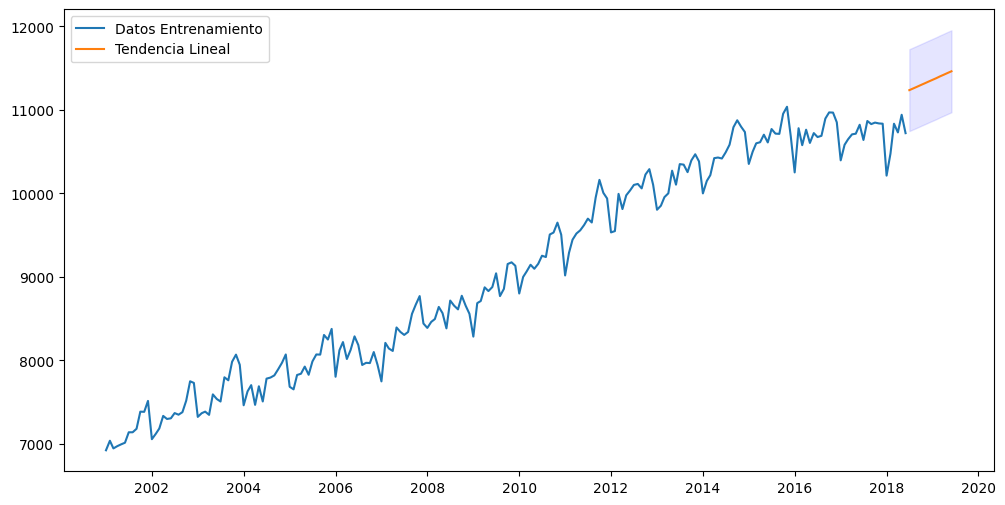

In [9]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label="Datos Entrenamiento")
plt.plot(test.index, preds_lin["Point_forecast"], label="Tendencia Lineal")
plt.fill_between(test.index, preds_lin["lower_95"], preds_lin["upper_95"], color="blue", alpha=0.1)
plt.legend()
plt.show()


In [10]:
rmse_lin = rmse(test.values, preds_lin["Point_forecast"].values)
print(f"RMSE Tendencia Lineal (fuera de muestra): {rmse_lin:,.2f}")


RMSE Tendencia Lineal (fuera de muestra): 625.87


## 5. Tendencia Cuadrática

In [11]:
y_train = train.values
x = np.linspace(1, n, n)
x2 = x**2
X = sm.add_constant(np.column_stack([x, x2]))
pol = sm.OLS(y_train, X)
pol_2 = pol.fit()
print(pol_2.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     2681.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          1.02e-148
Time:                        01:09:29   Log-Likelihood:                -1452.9
No. Observations:                 210   AIC:                             2912.
Df Residuals:                     207   BIC:                             2922.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6864.6609     51.494    133.311      0.0

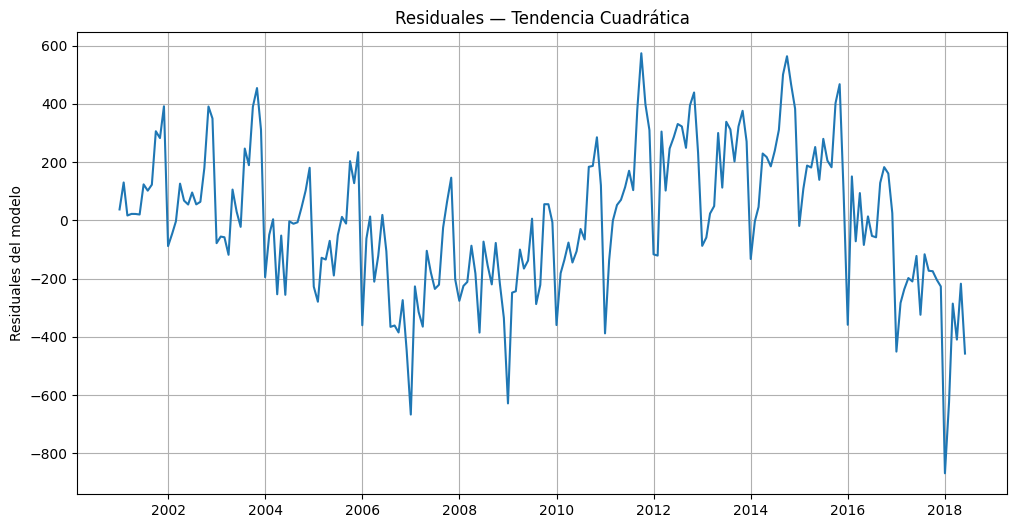

In [12]:
plt.ylabel("Residuales del modelo")
plt.plot(train.index, pol_2.resid)
plt.grid()
plt.title("Residuales — Tendencia Cuadrática")
plt.show()


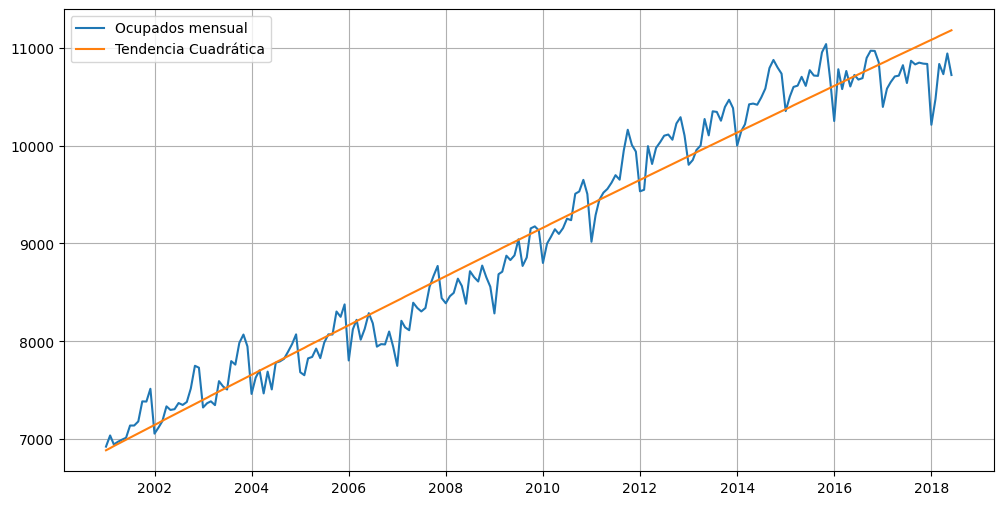

In [13]:
plt.plot(train.index, y_train, label="Ocupados mensual")
plt.plot(train.index, pol_2.fittedvalues, label="Tendencia Cuadrática")
plt.legend()
plt.grid()
plt.show()


In [14]:
h = 12
x_for = np.linspace(n+1, n+h, h)
x2_for = x_for**2
X_for = sm.add_constant(np.column_stack([x_for, x2_for]))

dt = pol_2.get_prediction(X_for).summary_frame(alpha=0.05)
y_prd = dt["mean"]
yprd_ci_lower = dt["obs_ci_lower"]
yprd_ci_upper = dt["obs_ci_upper"]
preds_pol = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds_pol.columns = ["Point_forecast", "lower_95", "upper_95"]
preds_pol.index = test.index
print(preds_pol)


            Point_forecast      lower_95      upper_95
mes                                                   
2018-07-01    11197.773246  10701.557323  11693.989168
2018-08-01    11217.221516  10720.604512  11713.838520
2018-09-01    11236.659523  10739.628445  11733.690602
2018-10-01    11256.087269  10758.628888  11753.545650
2018-11-01    11275.504751  10777.605603  11773.403900
2018-12-01    11294.911972  10796.558353  11793.265591
2019-01-01    11314.308930  10815.486901  11813.130959
2019-02-01    11333.695626  10834.391009  11833.000244
2019-03-01    11353.072060  10853.270437  11852.873683
2019-04-01    11372.438231  10872.124947  11872.751515
2019-05-01    11391.794140  10890.954300  11892.633980
2019-06-01    11411.139786  10909.758257  11912.521316


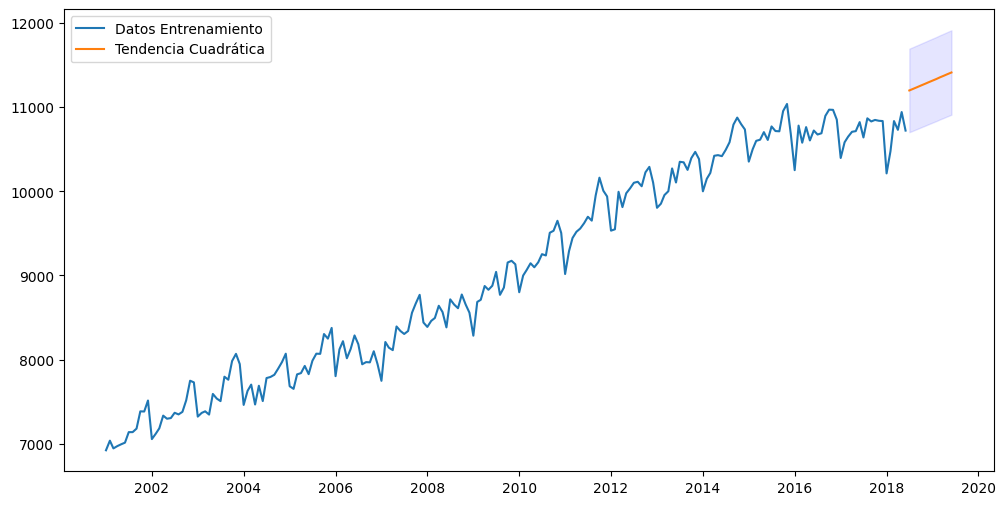

In [15]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train.index, y_train, label="Datos Entrenamiento")
plt.plot(test.index, preds_pol["Point_forecast"], label="Tendencia Cuadrática")
plt.fill_between(test.index, preds_pol["lower_95"], preds_pol["upper_95"], color="blue", alpha=0.1)
plt.legend()
plt.show()


In [16]:
rmse_pol = rmse(test.values, preds_pol["Point_forecast"].values)
print(f"RMSE Tendencia Cuadrática (fuera de muestra): {rmse_pol:,.2f}")


RMSE Tendencia Cuadrática (fuera de muestra): 583.39


## 6. Estimación de la Estacionalidad

In [17]:
month_dummies = pd.get_dummies(train.index.month, drop_first=True, dtype=float).set_index(train.index)

y_train_s = train
X = sm.add_constant(month_dummies)
sea = sm.OLS(y_train_s, X)
season = sea.fit()
print(season.summary())


                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.041
Method:                 Least Squares   F-statistic:                    0.2598
Date:                Wed, 17 Jun 2026   Prob (F-statistic):              0.992
Time:                        01:09:31   Log-Likelihood:                -1797.1
No. Observations:                 210   AIC:                             3618.
Df Residuals:                     198   BIC:                             3658.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8724.5387    305.798     28.530      0.0

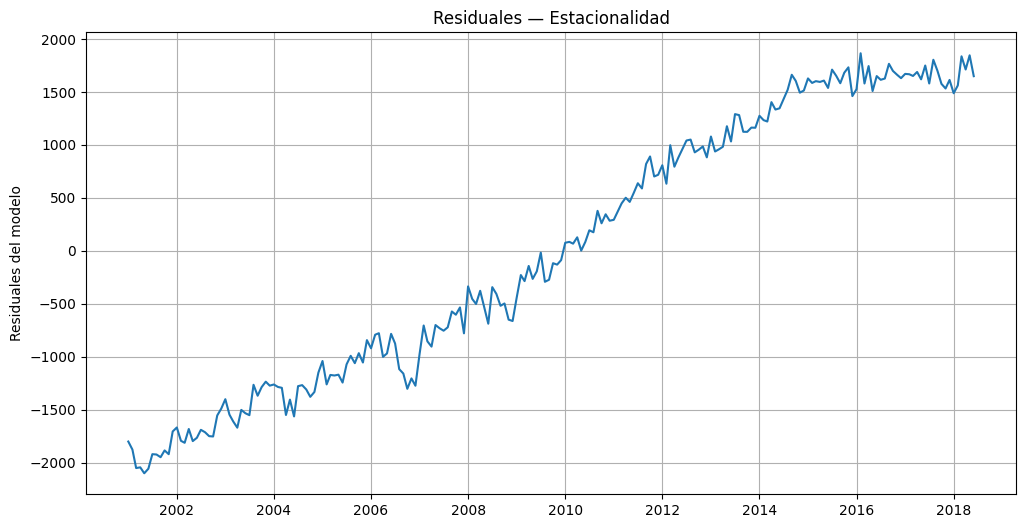

In [18]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()
plt.title("Residuales — Estacionalidad")
plt.show()


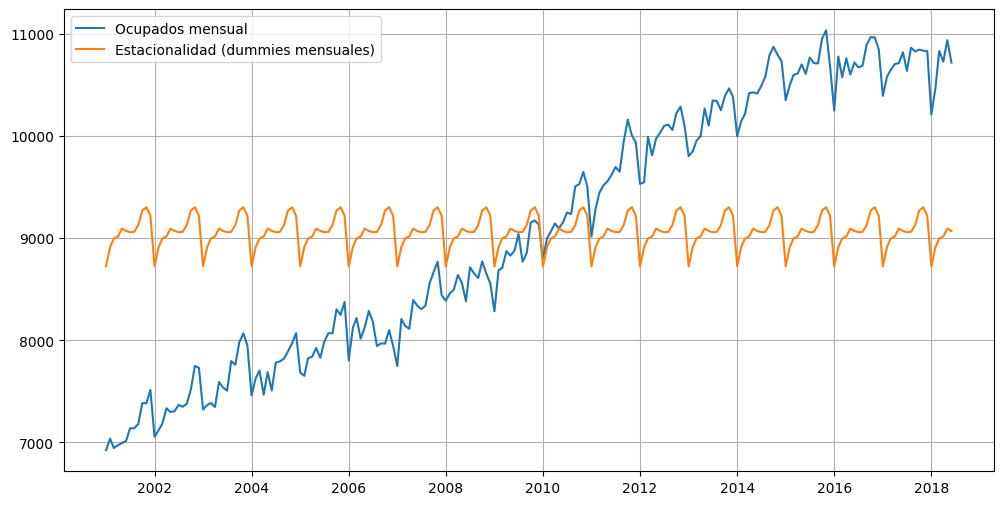

In [19]:
plt.plot(y_train_s, label="Ocupados mensual")
plt.plot(season.fittedvalues, label="Estacionalidad (dummies mensuales)")
plt.legend()
plt.grid()
plt.show()


In [20]:
range_dates = pd.date_range(train.index[-1] + relativedelta(months=1), periods=12, freq="MS")

x_for = pd.get_dummies(range_dates.month, drop_first=True, dtype=float)
x_for = x_for.reindex(columns=month_dummies.columns, fill_value=0.0)
X_for = sm.add_constant(x_for, has_constant="add")


In [21]:
dt = season.get_prediction(X_for).summary_frame(alpha=0.05)
y_prd = dt["mean"]
yprd_ci_lower = dt["obs_ci_lower"]
yprd_ci_upper = dt["obs_ci_upper"]
preds_sea = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds_sea.columns = ["Point_forecast", "lower_95", "upper_95"]
preds_sea.set_index(range_dates, inplace=True)
print(preds_sea)


            Point_forecast     lower_95      upper_95
2018-07-01     9059.390353  6426.740194  11692.040511
2018-08-01     9062.507118  6429.856959  11695.157276
2018-09-01     9129.933235  6497.283077  11762.583394
2018-10-01     9270.852412  6638.202253  11903.502570
2018-11-01     9304.549471  6671.899312  11937.199629
2018-12-01     9220.622941  6587.972783  11853.273100
2019-01-01     8724.538722  6095.954435  11353.123009
2019-02-01     8914.544389  6285.960102  11543.128676
2019-03-01     8997.218333  6368.634046  11625.802620
2019-04-01     9017.681722  6389.097435  11646.266009
2019-05-01     9095.089000  6466.504713  11723.673287
2019-06-01     9071.789000  6443.204713  11700.373287


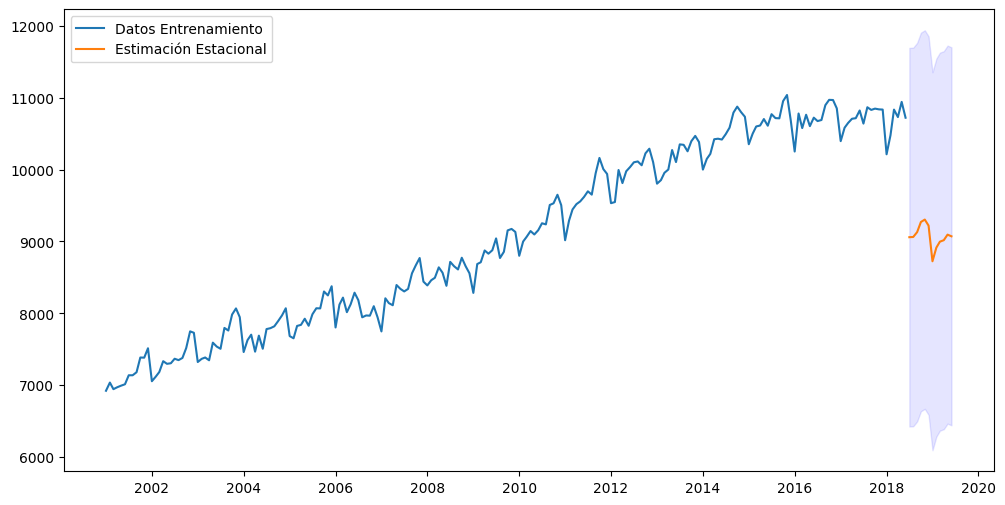

In [22]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y_train_s.index, y_train_s, label="Datos Entrenamiento")
plt.plot(preds_sea.index, preds_sea["Point_forecast"], label="Estimación Estacional")
plt.fill_between(preds_sea.index, preds_sea["lower_95"], preds_sea["upper_95"], color="blue", alpha=0.1)
plt.legend()
plt.show()


In [23]:
rmse_sea = rmse(test.values, preds_sea["Point_forecast"].values)
print(f"RMSE Estacionalidad (fuera de muestra): {rmse_sea:,.2f}")


RMSE Estacionalidad (fuera de muestra): 1,691.57


El modelo de estacionalidad pura (sin componente de tendencia) tiene un ajuste muy pobre ($R^2$ cercano a cero), ya que la serie de Ocupados está dominada por una tendencia de crecimiento de largo plazo que este modelo no captura. Como era de esperarse, su error de pronóstico fuera de muestra es considerablemente mayor que el de los modelos con tendencia.


## 7. Tendencia + Estacionalidad

In [24]:
y_train_ts = train
x = np.linspace(1, n, n)
x2 = x**2

month_dummies = pd.get_dummies(train.index.month, drop_first=True, dtype=float).set_index(train.index)
X = sm.add_constant(pd.concat([pd.DataFrame({"x": x, "x2": x2}, index=train.index), month_dummies], axis=1))

season_pol2 = sm.OLS(y_train_ts, X)
season_pol_2 = season_pol2.fit()
print(season_pol_2.summary())


                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     553.4
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          1.05e-146
Time:                        01:09:32   Log-Likelihood:                -1417.5
No. Observations:                 210   AIC:                             2863.
Df Residuals:                     196   BIC:                             2910.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6589.4780     65.076    101.259      0.0

In [25]:
X


,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,
2001-01-01,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-02-01,1.0,2.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-03-01,1.0,3.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-04-01,1.0,4.0,16.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2001-05-01,1.0,5.0,25.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-01,1.0,206.0,42436.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-03-01,1.0,207.0,42849.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-01,1.0,208.0,43264.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


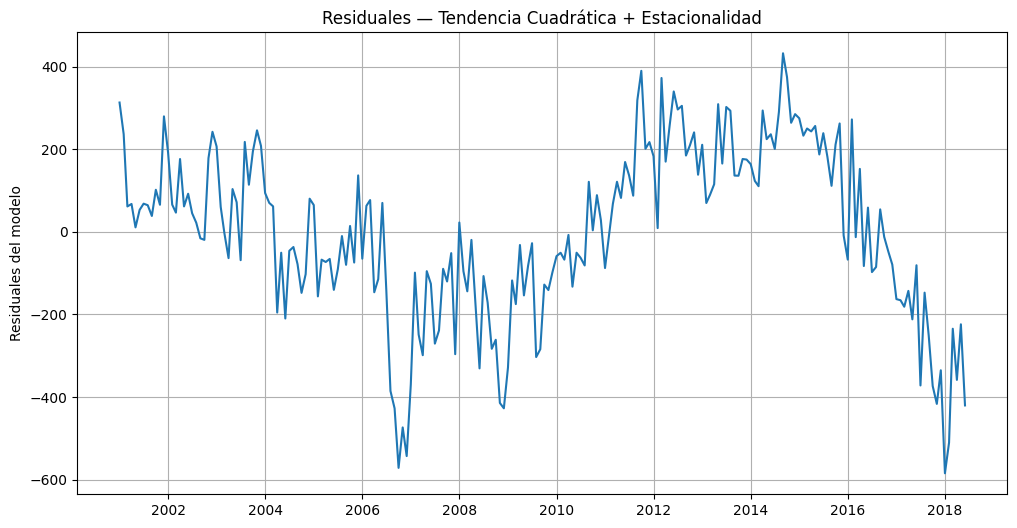

In [26]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol_2.resid)
plt.grid()
plt.title("Residuales — Tendencia Cuadrática + Estacionalidad")
plt.show()


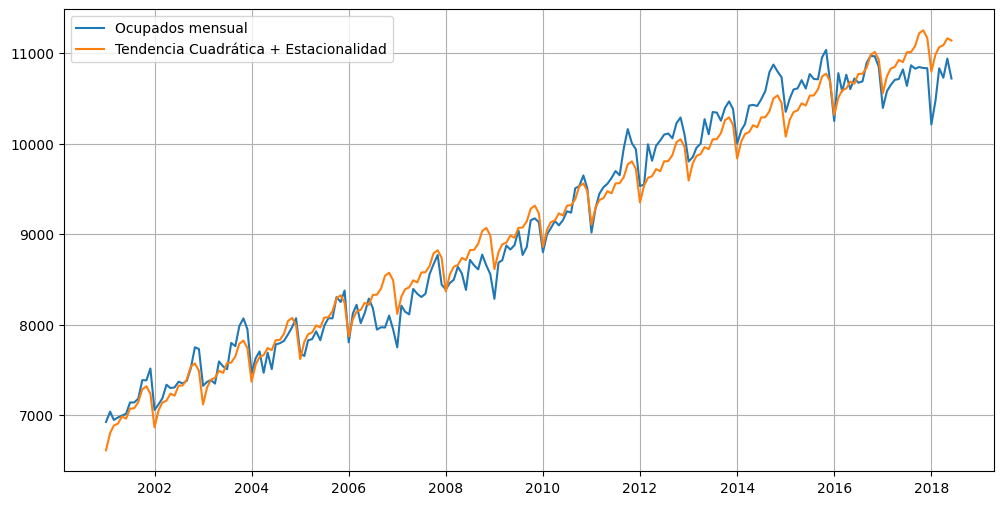

In [27]:
plt.plot(y_train_ts, label="Ocupados mensual")
plt.plot(season_pol_2.fittedvalues, label="Tendencia Cuadrática + Estacionalidad")
plt.legend()
plt.grid()
plt.show()


In [28]:
h = 12
x_for = np.linspace(n+1, n+h, h)
x_for_all = pd.DataFrame(np.column_stack([x_for, x_for**2]), columns=["x", "x2"])

range_dates = pd.date_range(train.index[-1] + relativedelta(months=1), periods=h, freq="MS")
x_for_dummies = pd.get_dummies(range_dates.month, drop_first=True, dtype=float)
x_for_dummies = x_for_dummies.reindex(columns=month_dummies.columns, fill_value=0.0)

X_for = sm.add_constant(pd.concat([x_for_all, x_for_dummies.reset_index(drop=True)], axis=1), has_constant="add")
X_for


,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
0,1.0,211.0,44521.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,212.0,44944.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,213.0,45369.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,214.0,45796.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,215.0,46225.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,1.0,216.0,46656.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,1.0,217.0,47089.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,218.0,47524.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,219.0,47961.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,220.0,48400.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
dt = season_pol_2.get_prediction(X_for).summary_frame(alpha=0.05)
y_prd = dt["mean"]
yprd_ci_lower = dt["obs_ci_lower"]
yprd_ci_upper = dt["obs_ci_upper"]
preds_seapol = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds_seapol.columns = ["Point_forecast", "lower_95", "upper_95"]
preds_seapol.set_index(range_dates, inplace=True)
print(preds_seapol)


            Point_forecast      lower_95      upper_95
2018-07-01    11250.009378  10807.598658  11692.420098
2018-08-01    11252.445860  10809.736253  11695.155468
2018-09-01    11319.191696  10876.175109  11762.208283
2018-10-01    11459.430590  11016.098948  11902.762232
2018-11-01    11492.447367  11048.792612  11936.102122
2018-12-01    11407.840555  10963.854646  11851.826465
2019-01-01    11035.422653  10592.049647  11478.795659
2019-02-01    11224.710244  10780.986501  11668.433987
2019-03-01    11306.666113  10862.582690  11750.749535
2019-04-01    11326.411426  10881.959404  11770.863448
2019-05-01    11403.100628  10958.271109  11847.930148
2019-06-01    11379.082553  10933.866661  11824.298445


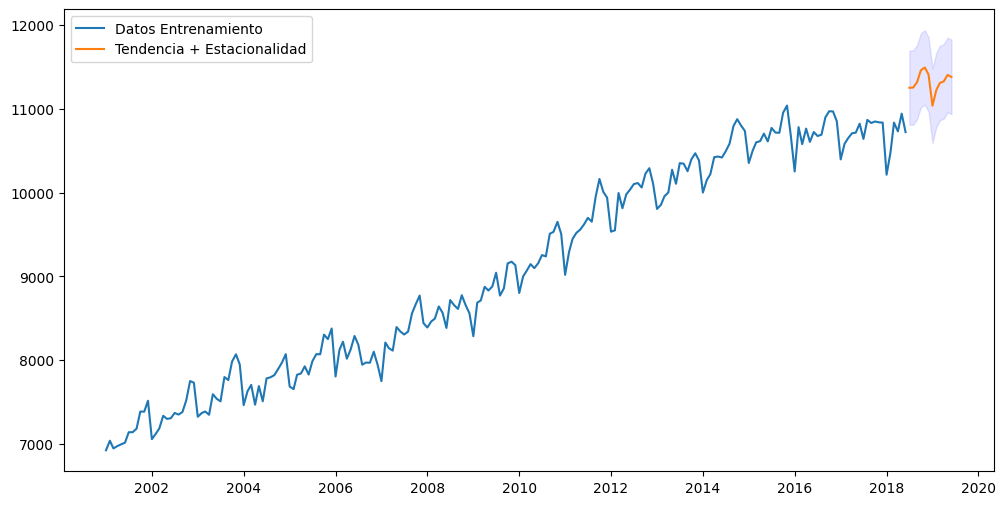

In [30]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y_train_ts.index, y_train_ts, label="Datos Entrenamiento")
plt.plot(preds_seapol.index, preds_seapol["Point_forecast"], label="Tendencia + Estacionalidad")
plt.fill_between(preds_seapol.index, preds_seapol["lower_95"], preds_seapol["upper_95"], color="blue", alpha=0.1)
plt.legend()
plt.show()


In [31]:
rmse_seapol = rmse(test.values, preds_seapol["Point_forecast"].values)
print(f"RMSE Tendencia Cuadrática + Estacionalidad (fuera de muestra): {rmse_seapol:,.2f}")


RMSE Tendencia Cuadrática + Estacionalidad (fuera de muestra): 576.61


## 8. Comparación de los modelos de regresión

Se compara el desempeño fuera de muestra (RMSE sobre el conjunto de prueba, julio 2018–junio 2019) de las cuatro especificaciones de regresión evaluadas.


In [32]:
tabla_reg = pd.DataFrame({
    "RMSE_test": {
        "Tendencia Lineal": rmse_lin,
        "Tendencia Cuadratica": rmse_pol,
        "Estacionalidad (dummies)": rmse_sea,
        "Tendencia Cuadratica + Estacionalidad": rmse_seapol,
    },
    "R2_train": {
        "Tendencia Lineal": lin_t.rsquared,
        "Tendencia Cuadratica": pol_2.rsquared,
        "Estacionalidad (dummies)": season.rsquared,
        "Tendencia Cuadratica + Estacionalidad": season_pol_2.rsquared,
    },
    "AIC": {
        "Tendencia Lineal": lin_t.aic,
        "Tendencia Cuadratica": pol_2.aic,
        "Estacionalidad (dummies)": season.aic,
        "Tendencia Cuadratica + Estacionalidad": season_pol_2.aic,
    }
}).sort_values("RMSE_test")

tabla_reg


,RMSE_test,R2_train,AIC
Tendencia Cuadratica + Estacionalidad,576.611209,0.973477,2862.965596
Tendencia Cuadratica,583.393049,0.962836,2911.806610
Tendencia Lineal,625.865042,0.962659,2910.802572
Estacionalidad (dummies),1691.573465,0.014226,3618.203861


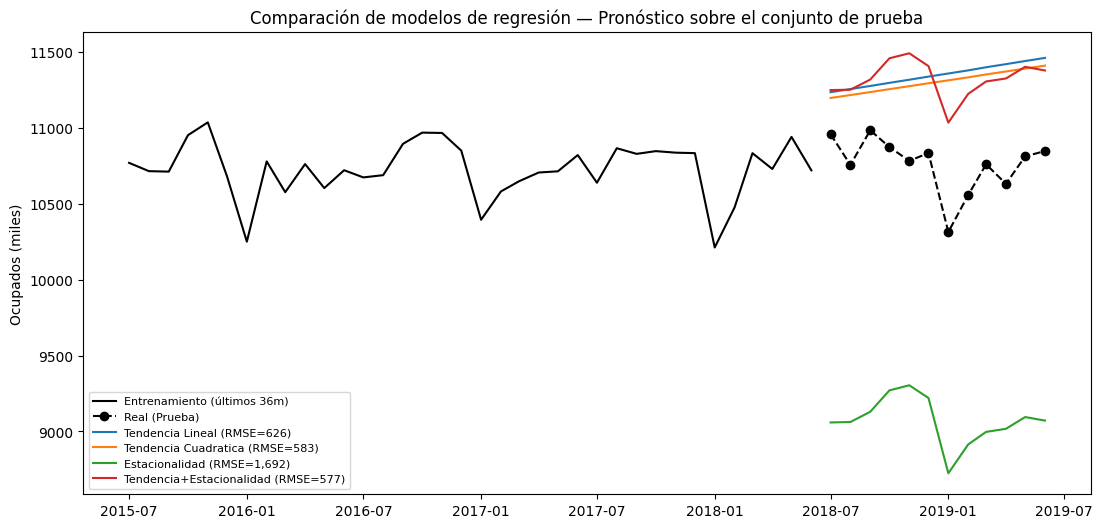

In [33]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-36:], train.values[-36:], label="Entrenamiento (últimos 36m)", color="black")
ax.plot(test.index, test.values, label="Real (Prueba)", color="black", linestyle="--", marker="o")
ax.plot(test.index, preds_lin["Point_forecast"], label=f"Tendencia Lineal (RMSE={rmse_lin:,.0f})")
ax.plot(test.index, preds_pol["Point_forecast"], label=f"Tendencia Cuadratica (RMSE={rmse_pol:,.0f})")
ax.plot(preds_sea.index, preds_sea["Point_forecast"], label=f"Estacionalidad (RMSE={rmse_sea:,.0f})")
ax.plot(preds_seapol.index, preds_seapol["Point_forecast"], label=f"Tendencia+Estacionalidad (RMSE={rmse_seapol:,.0f})")
ax.set_title("Comparación de modelos de regresión — Pronóstico sobre el conjunto de prueba")
ax.set_ylabel("Ocupados (miles)")
ax.legend(fontsize=8)
plt.show()


**Mejor modelo de regresión:** la especificación de **Tendencia Cuadrática + Estacionalidad** obtiene el menor RMSE fuera de muestra y el mayor $R^2$ dentro de la familia de modelos de regresión evaluados, por lo que es la que se selecciona para representar a este enfoque en la comparación final.


## 9. Evaluación de los Supuestos de los Residuales — Mejor Modelo de Regresión

Para poder hacer uso del modelo de **Tendencia Cuadrática + Estacionalidad** y de sus pronósticos, se deben cumplir los supuestos del Teorema de Gauss-Markov sobre los residuales: ausencia de autocorrelación, homoscedasticidad y, si se desea hacer inferencia exacta, normalidad.


### 9.1 Autocorrelación (Box-Pierce y Ljung-Box)

In [34]:
Resul_lb_bp = sm.stats.acorr_ljungbox(season_pol_2.resid, lags=range(1,21), return_df=True, boxpierce=True)
Resul_lb_bp["lb_ho"] = np.where(Resul_lb_bp["lb_pvalue"] < 0.05, "rechazo_ho/hay_autocorr", "no_rechazo_ho/no_hay_autocorr")
Resul_lb_bp["bp_ho"] = np.where(Resul_lb_bp["bp_pvalue"] < 0.05, "rechazo_ho/hay_autocorr", "no_rechazo_ho/no_hay_autocorr")

Resul_lb_bp


,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_ho,bp_ho
1,136.263664,1.747192e-31,134.335404,4.614319e-31,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,258.388628,7.791523e-57,254.156124,6.466941e-56,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,370.968915,4.294359e-80,364.081216,1.331974e-78,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,466.468426,1.194865e-99,456.877910,1.415434e-97,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,549.381844,1.738794e-116,537.053621,7.990188e-114,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,624.182483,1.415182e-131,609.031595,2.627312e-128,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,691.433202,4.847916e-145,673.427330,3.689061e-141,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,751.980110,4.575530e-157,731.118252,1.425540e-152,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,810.333286,1.268221e-168,786.443669,1.759493e-163,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,860.972717,1.591553e-178,834.216716,9.059428e-173,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


### 9.2 Homoscedasticidad (Ljung-Box sobre residuales al cuadrado)

In [35]:
resid_c = season_pol_2.resid
sm.stats.acorr_ljungbox((resid_c - resid_c.mean())**2, lags=range(1,21), return_df=True, boxpierce=True)


,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,80.030297,3.687126e-19,78.897793,6.540780e-19
2,126.494932,3.403882e-28,124.485737,9.295349e-28
3,155.980486,1.350520e-33,153.275877,5.176657e-33
4,167.926150,2.914271e-35,164.883456,1.310375e-34
5,172.881806,1.770719e-35,169.675482,8.557373e-35
6,175.220627,3.510089e-35,171.926045,1.755619e-34
7,175.592007,1.660317e-34,172.281659,8.290844e-34
8,175.799917,7.838854e-34,172.479762,3.896386e-33
9,175.879756,3.669719e-33,172.555458,1.810624e-32
10,176.164416,1.464431e-32,172.824006,7.213785e-32


### 9.3 Normalidad

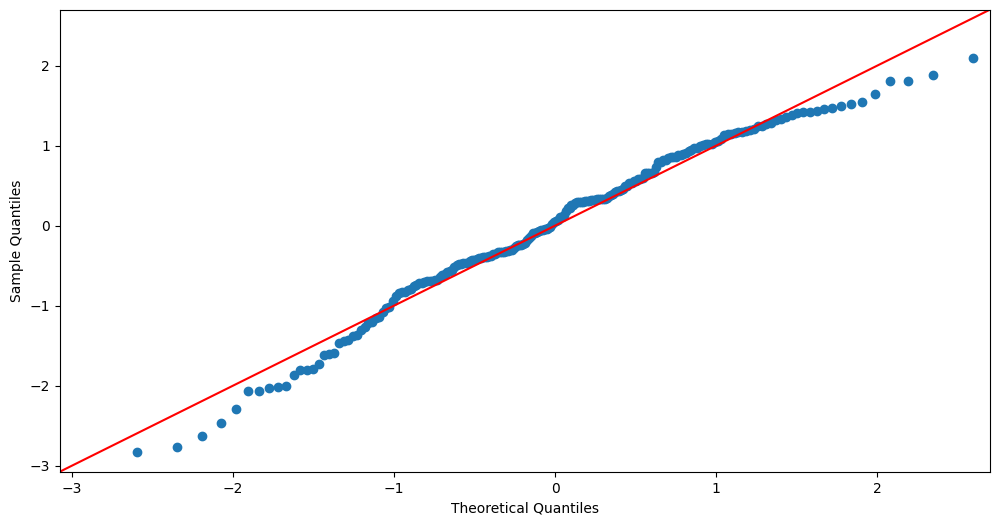

In [44]:
sm.qqplot(season_pol_2.resid, line="45", fit=True)
py.show()


In [37]:
print("Shapiro-Wilk:", stats.shapiro(season_pol_2.resid))
print("Jarque-Bera:", stats.jarque_bera(season_pol_2.resid))


Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9788364736017784), pvalue=np.float64(0.0029803986286153373))
Jarque-Bera: SignificanceResult(statistic=np.float64(7.502469135345184), pvalue=np.float64(0.023488729522242322))


**Diagnóstico:** la prueba de Ljung-Box muestra evidencia de **autocorrelación significativa en varios rezagos** de los residuales del modelo de Tendencia Cuadrática + Estacionalidad (p-valores menores a 0.05 en múltiples rezagos), lo cual indica que el modelo **no logra capturar toda la estructura dinámica de la serie** — consistente con la inflexión de tendencia observada hacia 2015–2016, que un componente de tendencia global no puede modelar adecuadamente. Esto compromete la validez de los intervalos de confianza basados en los supuestos clásicos de OLS y constituye, junto con el RMSE más alto, una razón adicional para preferir un modelo más flexible.


## 10. Mejor Modelo ETS (Ejercicio Anterior)

Como referencia de comparación, se reestima el mejor modelo de suavización exponencial encontrado en el ejercicio anterior: **ETS(A,N,M)** — Holt-Winters multiplicativo sin componente de tendencia — bajo la misma partición entrenamiento/prueba, para hacer la comparación de RMSE en igualdad de condiciones.


In [38]:
modelo_ets = ExponentialSmoothing(train, trend=None, seasonal="mul", seasonal_periods=12,
                                   initialization_method="estimated").fit()
f_ets_test = modelo_ets.forecast(12)

rmse_ets = rmse(test.values, f_ets_test.values)
print(f"RMSE ETS(A,N,M) (fuera de muestra): {rmse_ets:,.2f}")


RMSE ETS(A,N,M) (fuera de muestra): 121.63


## 11. Comparación Final: Mejor Modelo de Regresión vs. Mejor Modelo ETS


In [39]:
comparacion_final = pd.DataFrame({
    "Modelo": ["Tendencia Cuadrática + Estacionalidad (Regresión)", "ETS(A,N,M) - Holt-Winters mult. sin tendencia"],
    "RMSE_test": [rmse_seapol, rmse_ets]
}).sort_values("RMSE_test")

comparacion_final


,Modelo,RMSE_test
1,"ETS(A,N,M) - Holt-Winters mult. sin tendencia",121.627353
0,Tendencia Cuadrática + Estacionalidad (Regresión),576.611209


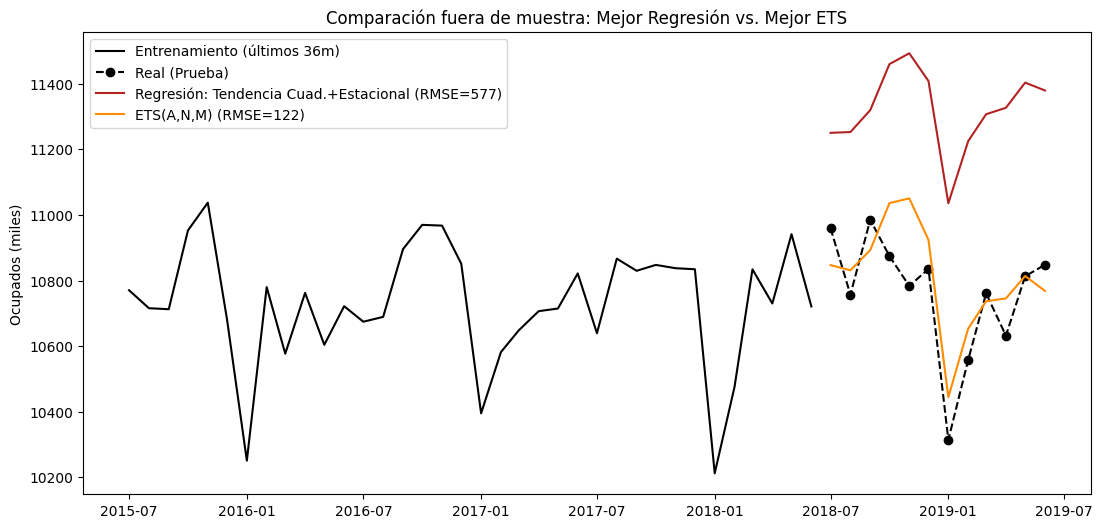

In [40]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-36:], train.values[-36:], label="Entrenamiento (últimos 36m)", color="black")
ax.plot(test.index, test.values, label="Real (Prueba)", color="black", linestyle="--", marker="o")
ax.plot(preds_seapol.index, preds_seapol["Point_forecast"], label=f"Regresión: Tendencia Cuad.+Estacional (RMSE={rmse_seapol:,.0f})", color="firebrick")
ax.plot(f_ets_test.index, f_ets_test.values, label=f"ETS(A,N,M) (RMSE={rmse_ets:,.0f})", color="darkorange")
ax.set_title("Comparación fuera de muestra: Mejor Regresión vs. Mejor ETS")
ax.set_ylabel("Ocupados (miles)")
ax.legend()
plt.show()


El modelo de regresión, al estimar una **tendencia global determinística** sobre toda la muestra de entrenamiento, no logra adaptarse al cambio de pendiente que ocurre en los últimos años de la serie y termina **sobreestimando sistemáticamente** los valores del periodo de prueba, además de dejar autocorrelación significativa en los residuales (sección 9). El modelo ETS, en cambio, actualiza su componente de nivel de forma recursiva, dando mayor peso a las observaciones recientes, lo que le permite **seguir más de cerca el quiebre de tendencia** y producir un error de pronóstico considerablemente menor.

**Conclusión de la comparación:** el modelo **ETS(A,N,M)** es claramente superior al mejor modelo de regresión (Tendencia Cuadrática + Estacionalidad) para esta serie, por lo que se utiliza para las proyecciones finales.


## 12. Pronóstico Final a 6 Meses (Julio–Diciembre 2019)

Una vez confirmado que **ETS(A,N,M)** es el mejor modelo entre todas las alternativas evaluadas (tanto de regresión como de suavización exponencial), se reestima usando **toda la información disponible** (enero 2001–junio 2019) y se generan los pronósticos puntuales e intervalos de confianza al 95% para los siguientes 6 meses.


In [41]:
modelo_final = ExponentialSmoothing(y, trend=None, seasonal="mul", seasonal_periods=12,
                                     initialization_method="estimated").fit()

h = 6
pron_final = modelo_final.forecast(h)

np.random.seed(42)
sim = modelo_final.simulate(h, repetitions=2000, error="mul")
ic_inf = sim.quantile(0.025, axis=1)
ic_sup = sim.quantile(0.975, axis=1)

tabla_pron = pd.DataFrame({
    "Pronostico_puntual": pron_final.values,
    "IC_inferior_95": ic_inf.values,
    "IC_superior_95": ic_sup.values
}, index=pron_final.index)

tabla_pron.index.name = "Mes"
tabla_pron.round(2)


,Pronostico_puntual,IC_inferior_95,IC_superior_95
Mes,,,
2019-07-01,10888.02,10611.45,11192.69
2019-08-01,10857.36,10537.17,11208.93
2019-09-01,10931.97,10550.76,11311.55
2019-10-01,11055.74,10634.22,11491.25
2019-11-01,11062.26,10632.01,11532.13
2019-12-01,10948.49,10474.49,11435.38


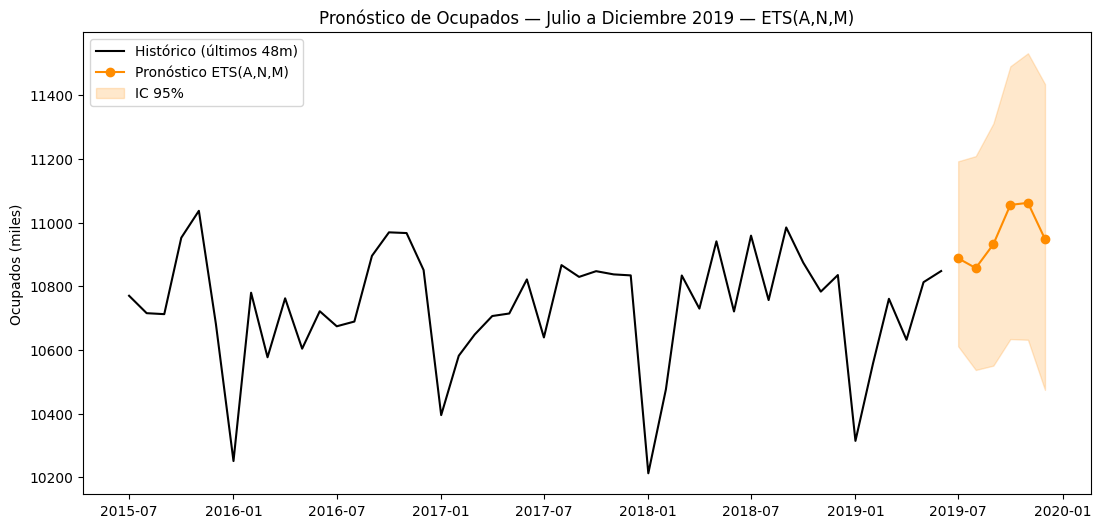

In [42]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(y.index[-48:], y.values[-48:], label="Histórico (últimos 48m)", color="black")
ax.plot(tabla_pron.index, tabla_pron["Pronostico_puntual"], label="Pronóstico ETS(A,N,M)", color="darkorange", marker="o")
ax.fill_between(tabla_pron.index, tabla_pron["IC_inferior_95"], tabla_pron["IC_superior_95"],
                color="darkorange", alpha=0.2, label="IC 95%")
ax.set_title("Pronóstico de Ocupados — Julio a Diciembre 2019 — ETS(A,N,M)")
ax.set_ylabel("Ocupados (miles)")
ax.legend()
plt.show()


## 13. Tabla Resumen de Pronósticos Finales

In [43]:
meses_es = {1:"Enero",2:"Febrero",3:"Marzo",4:"Abril",5:"Mayo",6:"Junio",
            7:"Julio",8:"Agosto",9:"Septiembre",10:"Octubre",11:"Noviembre",12:"Diciembre"}

resumen = tabla_pron.copy()
resumen.columns = ["Pronóstico Puntual", "Límite Inferior (95%)", "Límite Superior (95%)"]
resumen.index = [f"{meses_es[d.month]} {d.year}" for d in resumen.index]
resumen.round(2)


,Pronóstico Puntual,Límite Inferior (95%),Límite Superior (95%)
Julio 2019,10888.02,10611.45,11192.69
Agosto 2019,10857.36,10537.17,11208.93
Septiembre 2019,10931.97,10550.76,11311.55
Octubre 2019,11055.74,10634.22,11491.25
Noviembre 2019,11062.26,10632.01,11532.13
Diciembre 2019,10948.49,10474.49,11435.38


## 14. Conclusión

Siguiendo el pipeline de regresión con tendencia y estacionalidad del ejercicio anterior, aplicado ahora a la serie de **Ocupados**, la mejor especificación dentro de esa familia es **Tendencia Cuadrática + Estacionalidad** (RMSE fuera de muestra ≈ 577), aunque sus residuales muestran autocorrelación significativa, señal de que el modelo no captura del todo la dinámica de la serie. Al comparar este resultado contra el mejor modelo de suavización exponencial, **ETS(A,N,M)** (RMSE ≈ 122), el ETS resulta claramente superior, por lo que es el modelo utilizado para las proyecciones finales de julio a diciembre de 2019. El detalle metodológico completo, las proyecciones puntuales con sus intervalos de confianza y las limitaciones del pronóstico se presentan en el informe adjunto.
